# AI 기반 금융권 IT감사 사전 통제 점검 분석
> 법령 기반 Rule 엔진 위반 탐지 결과 분석

## 0. 환경 설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)

BASE = '../data'
print('환경 설정 완료')

Matplotlib is building the font cache; this may take a moment.


환경 설정 완료


## 1. 데이터 로드

In [3]:
# 전처리된 가상 DB
df_emp     = pd.read_csv(f'{BASE}/processed/virtual_db/emp_master.csv',   encoding='utf-8-sig')
df_account = pd.read_csv(f'{BASE}/processed/virtual_db/sys_account.csv',  encoding='utf-8-sig')
df_access  = pd.read_csv(f'{BASE}/processed/virtual_db/access_log.csv',   encoding='utf-8-sig')
df_itsm    = pd.read_csv(f'{BASE}/processed/virtual_db/itsm_req.csv',     encoding='utf-8-sig')
df_deploy  = pd.read_csv(f'{BASE}/processed/virtual_db/deploy_log.csv',   encoding='utf-8-sig')
df_backup  = pd.read_csv(f'{BASE}/processed/virtual_db/backup_log.csv',   encoding='utf-8-sig')

# Rule 엔진 결과
df_violations = pd.read_csv(f'{BASE}/processed/violations_summary.csv', encoding='utf-8-sig')

# 날짜 컬럼 변환
for df, cols in [
    (df_emp,     ['hire_dt','resign_dt']),
    (df_account, ['last_review_dt','last_pw_change_dt']),
    (df_access,  ['access_dt']),
    (df_deploy,  ['deploy_dt']),
    (df_itsm,    ['request_dt','approval_dt']),
    (df_backup,  ['backup_dt']),
]:
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print('데이터 로드 완료')
print(f'  emp_master  : {len(df_emp):,}행')
print(f'  sys_account : {len(df_account):,}행')
print(f'  access_log  : {len(df_access):,}행')
print(f'  deploy_log  : {len(df_deploy):,}행')
print(f'  backup_log  : {len(df_backup):,}행')
print(f'  violations  : {len(df_violations):,}행')

데이터 로드 완료
  emp_master  : 500행
  sys_account : 1,195행
  access_log  : 322,445행
  deploy_log  : 184행
  backup_log  : 905행
  violations  : 70행


## 2. 전체 위반 현황 요약

In [4]:
total     = len(df_violations)
violated  = (df_violations['yn_violation'] == 'Y').sum()
clean     = total - violated

print('=' * 40)
print('IT감사 Rule 엔진 점검 결과')
print('=' * 40)
print(f'총 점검 규칙  : {total}개')
print(f'위반 탐지     : {violated}개 ({violated/total*100:.1f}%)')
print(f'이상 없음     : {clean}개 ({clean/total*100:.1f}%)')
print()

# 도메인별 요약
domain_summary = df_violations.groupby('audit_domain').agg(
    전체규칙=('rule_id','count'),
    위반규칙=('yn_violation', lambda x: (x=='Y').sum()),
    총위반건수=('violation_count','sum')
).reset_index()
domain_summary['위반율(%)'] = (domain_summary['위반규칙'] / domain_summary['전체규칙'] * 100).round(1)
print('[도메인별 위반 현황]')
print(domain_summary.to_string(index=False))

IT감사 Rule 엔진 점검 결과
총 점검 규칙  : 70개
위반 탐지     : 43개 (61.4%)
이상 없음     : 27개 (38.6%)

[도메인별 위반 현황]
audit_domain  전체규칙  위반규칙  총위반건수  위반율(%)
        변경관리    15    11    354    73.3
        운영통제    13     7     53    53.8
        접근통제    42    25  94366    59.5


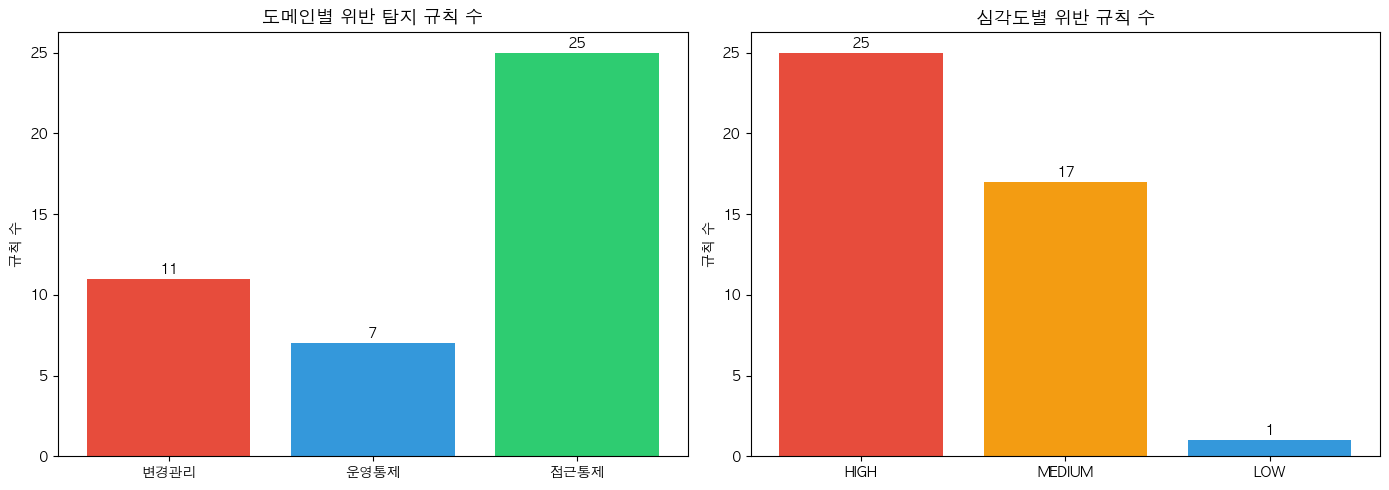

In [5]:
# 도메인별 위반 규칙 수 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 위반 규칙 수
colors = ['#e74c3c','#3498db','#2ecc71']
axes[0].bar(domain_summary['audit_domain'], domain_summary['위반규칙'], color=colors)
axes[0].set_title('도메인별 위반 탐지 규칙 수', fontsize=13)
axes[0].set_ylabel('규칙 수')
for i, v in enumerate(domain_summary['위반규칙']):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# 오른쪽: 심각도별 위반 규칙 수
sev_order = ['HIGH','MEDIUM','LOW']
sev_colors = {'HIGH':'#e74c3c','MEDIUM':'#f39c12','LOW':'#3498db'}
sev_data = df_violations[df_violations['yn_violation']=='Y'].groupby('severity').size().reindex(sev_order, fill_value=0)
axes[1].bar(sev_data.index, sev_data.values, color=[sev_colors[s] for s in sev_data.index])
axes[1].set_title('심각도별 위반 규칙 수', fontsize=13)
axes[1].set_ylabel('규칙 수')
for i, v in enumerate(sev_data.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. 접근통제 분석

In [6]:
# 3-1. 퇴사자 계정 미정리
resigned_ids = df_emp[df_emp['yn_employed']=='N']['emp_id'].tolist()
active_resigned = df_account[
    df_account['emp_id'].isin(resigned_ids) &
    (df_account['account_status']=='active')
].copy()

active_resigned = active_resigned.merge(
    df_emp[['emp_id','emp_nm','dept_nm','resign_dt']], on='emp_id', how='left'
)

print(f'퇴사자 활성 계정: {len(active_resigned)}건')
print(active_resigned[['emp_id','emp_nm','dept_nm','system_cd','account_status','resign_dt']].to_string(index=False))

퇴사자 활성 계정: 15건
 emp_id emp_nm dept_nm system_cd account_status  resign_dt
  11543    이동현  IT개발2팀      DEVP         active 2025-02-20
  11543    이동현  IT개발2팀      INFO         active 2025-02-20
  11664    김현지  IT개발1팀      DEVP         active 2023-12-26
  15216    최은주   정보보안팀     ADMIN         active 2025-02-18
  15242    한숙자   준법감시팀     ADMIN         active 2023-02-23
  16232    손춘자     기획팀     ADMIN         active 2024-08-12
  16693    강광수  IT개발1팀      INFO         active 2024-02-19
  17457    문지우    영업2팀     IBANK         active 2023-10-18
  18609    나종수    영업2팀     IBANK         active 2023-08-28
  21327    차선영   IT운영팀     ADMIN         active 2022-03-22
  22969    송현주    영업1팀     ADMIN         active 2023-06-07
  24299    김수진   준법감시팀     IBANK         active 2022-10-23
  26959    박준혁  IT개발1팀      INFO         active 2023-01-21
  27573    이영순   정보보안팀      INFO         active 2025-02-18
  29543    이현정   경영지원팀     ADMIN         active 2023-09-24


In [7]:
# 3-2. 권한검토 초과 계정
overdue = df_account[df_account['yn_overdue_review']=='Y'].copy()
overdue = overdue.merge(df_emp[['emp_id','dept_nm','role_type']], on='emp_id', how='left')

print(f'권한검토 180일 초과: {len(overdue)}건')
print()
print('[부서별 현황]')
print(overdue.groupby('dept_nm').size().sort_values(ascending=False).to_string())

권한검토 180일 초과: 30건

[부서별 현황]
dept_nm
영업1팀      5
IT개발1팀    3
IT개발2팀    3
IT운영팀     3
고객서비스팀    3
트레이딩팀     3
심사팀       2
영업2팀      2
정보보안팀     2
경영지원팀     1
기획팀       1
리스크관리팀    1
준법감시팀     1


In [8]:
# 3-3. 업무시간 외 접속
after_hours = df_access[df_access['yn_after_hours']=='Y'].copy()

print(f'업무시간 외(22~06시) 접속: {len(after_hours):,}건')
print()
print('[시스템별 현황]')
print(after_hours.groupby('system_cd').size().sort_values(ascending=False).to_string())
print()
print('[액션 유형별 현황]')
print(after_hours.groupby('action_type').size().sort_values(ascending=False).to_string())

업무시간 외(22~06시) 접속: 82건

[시스템별 현황]
system_cd
IBANK    41
ADMIN    28
INFO     10
CORE      3

[액션 유형별 현황]
action_type
UPDATE    25
EXPORT    23
QUERY     22
LOGIN     12


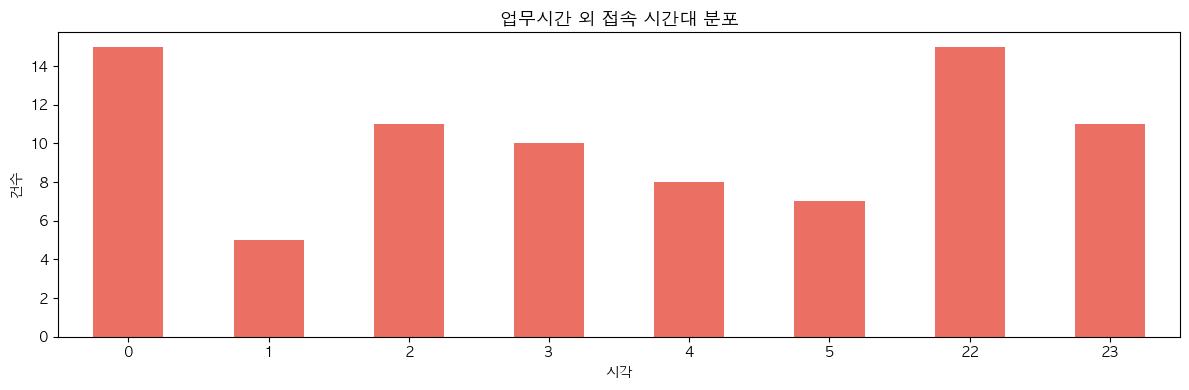

In [9]:
# 3-4. 업무시간 외 접속 시간대 분포
after_hours['hour'] = pd.to_datetime(after_hours['access_dt']).dt.hour

plt.figure(figsize=(12, 4))
after_hours['hour'].value_counts().sort_index().plot(kind='bar', color='#e74c3c', alpha=0.8)
plt.title('업무시간 외 접속 시간대 분포', fontsize=13)
plt.xlabel('시각')
plt.ylabel('건수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. 변경관리 분석

In [10]:
# 4-1. 변경관리 위반 3종 현황
no_cr    = df_deploy[df_deploy['yn_no_cr']=='Y']
post_app = df_deploy[df_deploy['yn_post_approval']=='Y']
job_sep  = df_deploy[df_deploy['yn_job_sep_violation']=='Y']

print('[변경관리 위반 현황]')
print(f'  CR 없는 무단 배포       : {len(no_cr):>3}건')
print(f'  사후 승인 배포          : {len(post_app):>3}건')
print(f'  직무분리 위반 (신청=배포): {len(job_sep):>3}건')

[변경관리 위반 현황]
  CR 없는 무단 배포       :  15건
  사후 승인 배포          :  20건
  직무분리 위반 (신청=배포):  15건


In [11]:
# 4-2. 사후 승인 배포 - 승인까지 걸린 시간 분포
post_app = post_app.merge(df_itsm[['doc_no','approval_dt','request_dt']], on='doc_no', how='left')
post_app['deploy_dt'] = pd.to_datetime(post_app['deploy_dt'])
post_app['approval_dt'] = pd.to_datetime(post_app['approval_dt'])
post_app['승인지연_시간'] = (post_app['approval_dt'] - post_app['deploy_dt']).dt.total_seconds() / 3600

print('[사후승인 배포: 배포→승인 소요 시간]')
print(post_app['승인지연_시간'].describe().round(1))

[사후승인 배포: 배포→승인 소요 시간]
count    20.0
mean     10.9
std       7.4
min       2.0
25%       3.8
50%       8.5
75%      16.5
max      23.0
Name: 승인지연_시간, dtype: float64


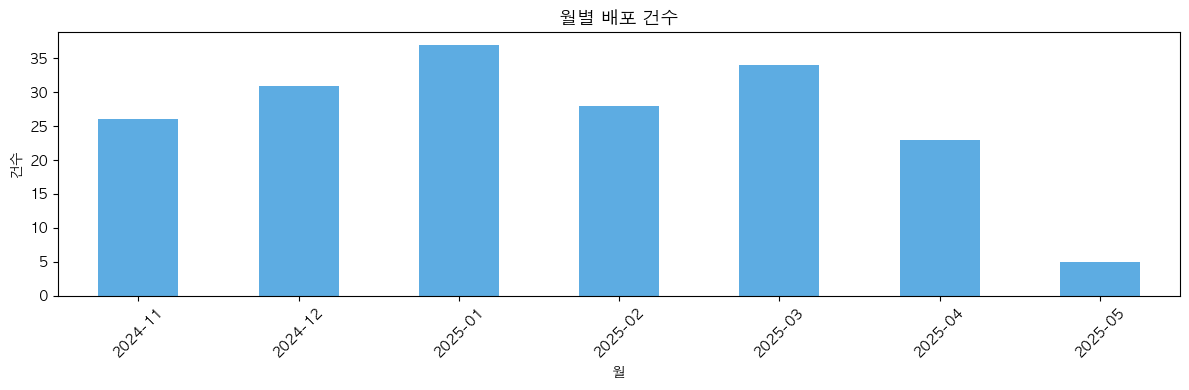

In [12]:
# 4-3. 월별 배포 건수 추이
df_deploy['월'] = pd.to_datetime(df_deploy['deploy_dt']).dt.to_period('M')
monthly = df_deploy.groupby('월').size()

plt.figure(figsize=(12, 4))
monthly.plot(kind='bar', color='#3498db', alpha=0.8)
plt.title('월별 배포 건수', fontsize=13)
plt.xlabel('월')
plt.ylabel('건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. 운영통제 분석

In [13]:
# 5-1. 백업 실패 현황
fail_backup = df_backup[df_backup['backup_status']=='F']
no_restore  = df_backup[(df_backup['backup_type']=='full') & (df_backup['yn_restore_test']=='N')]

print(f'백업 실패           : {len(fail_backup)}건')
print(f'복구테스트 미실시   : {len(no_restore)}건')
print()
print('[시스템별 백업 실패 현황]')
print(fail_backup.groupby('system_cd').size().sort_values(ascending=False).to_string())

백업 실패           : 20건
복구테스트 미실시   : 40건

[시스템별 백업 실패 현황]
system_cd
DEVP     6
ADMIN    5
INFO     4
IBANK    3
CORE     2


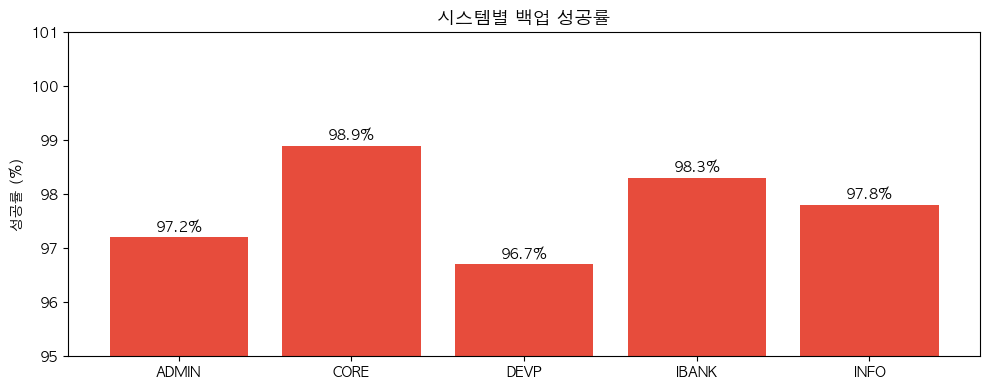

In [14]:
# 5-2. 시스템별 백업 성공률
backup_rate = df_backup.groupby('system_cd').apply(
    lambda x: (x['backup_status']=='S').sum() / len(x) * 100
).round(1).reset_index()
backup_rate.columns = ['system_cd', '백업성공률(%)']

plt.figure(figsize=(10, 4))
colors = ['#e74c3c' if v < 99 else '#2ecc71' for v in backup_rate['백업성공률(%)']]
plt.bar(backup_rate['system_cd'], backup_rate['백업성공률(%)'], color=colors)
plt.title('시스템별 백업 성공률', fontsize=13)
plt.ylabel('성공률 (%)')
plt.ylim(95, 101)
for i, v in enumerate(backup_rate['백업성공률(%)']):
    plt.text(i, v + 0.1, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

## 6. 인사이트 도출
> 아래 셀에 분석 결과를 직접 작성하세요

In [ ]:
# 6-1. 부서별 위험도 종합 점수
# 각 위반 유형별 부서 현황을 합산하여 위험 부서 식별

# ① 퇴사자 활성계정 (emp_id 기준)
resigned_ids = set(df_emp[df_emp['yn_employed']=='N']['emp_id'])
active_resigned = df_account[
    df_account['emp_id'].isin(resigned_ids) &
    (df_account['account_status']=='active')
].merge(df_emp[['emp_id','dept_nm']], on='emp_id', how='left')
risk_resign = active_resigned.groupby('dept_nm').size().rename('퇴사자계정')

# ② 권한검토 초과 (부서별)
overdue = df_account[df_account['yn_overdue_review']=='Y'].merge(
    df_emp[['emp_id','dept_nm']], on='emp_id', how='left')
risk_overdue = overdue.groupby('dept_nm').size().rename('권한검토초과')

# ③ 업무시간외 접속 (부서별)
after_hours = df_access[df_access['yn_after_hours']=='Y'].merge(
    df_emp[['emp_id','dept_nm']], on='emp_id', how='left')
risk_after = after_hours.groupby('dept_nm').size().rename('시간외접속')

# 종합
dept_risk = pd.concat([risk_resign, risk_overdue, risk_after], axis=1).fillna(0).astype(int)
dept_risk['위험점수'] = dept_risk['퇴사자계정'] * 3 + dept_risk['권한검토초과'] * 2 + dept_risk['시간외접속'] * 1
dept_risk = dept_risk.sort_values('위험점수', ascending=False)

print('[부서별 접근통제 위험도 (가중 점수)]')
print('  ※ 퇴사자계정 ×3점, 권한검토초과 ×2점, 시간외접속 ×1점')
print()
print(dept_risk.to_string())

In [ ]:
# 6-7. 종합 핵심 발견사항 요약 (보고서 인사이트용)
print('=' * 60)
print('  IT감사 핵심 발견사항 요약')
print('=' * 60)

print('''
【접근통제 분야 - 위험도: 高】
 1. 퇴사자 계정 15건 미삭제
    - 퇴사 후 최장 3년 이상 활성 계정 유지 (최고 위험)
    - 전자금융감독규정 제29조(접근권한 관리) 위반
    - IT운영팀·정보보안팀 등 민감부서 포함

 2. 권한검토 180일 초과 30건
    - 영업1팀(5건), IT개발팀(6건) 집중
    - 주기적 권한검토 의무 미이행

 3. 업무시간 외(22~06시) 접속 82건
    - UPDATE(25건)·EXPORT(23건) 등 고위험 액션 포함
    - 이상거래 여부 추가 검토 필요

【변경관리 분야 - 위험도: 中高】
 4. 무단 배포(CR 없음) 15건
    - 승인 절차 없이 운영계 배포 → 내부통제 공백

 5. 사후 승인 배포 20건
    - 배포 후 평균 10.9시간 뒤 승인 → 절차 형식화

 6. 직무분리 위반 15건
    - 신청자 = 배포자 동일인 → 상호검증 불가

【운영통제 분야 - 위험도: 中】
 7. 백업 실패 20건 (DEVP 6건 최다)
 8. FULL 백업 복구테스트 미실시 40건
    - 장애 발생 시 실제 복구 가능 여부 미확인
''')

print('=' * 60)
print(f'  점검 규칙 {len(df_violations)}개 중 {(df_violations["yn_violation"]=="Y").sum()}개 위반 탐지 ({(df_violations["yn_violation"]=="Y").sum()/len(df_violations)*100:.1f}%)')
print('=' * 60)

In [ ]:
# 6-6. 운영통제 심화: 백업 실패 월별 추이 + 복구테스트 미실시 비율
df_backup['월'] = df_backup['backup_dt'].dt.to_period('M')

# 월별 백업 실패율
monthly_backup = df_backup.groupby('월').agg(
    전체=('backup_seq','count'),
    실패=('backup_status', lambda x: (x=='F').sum())
).reset_index()
monthly_backup['실패율(%)'] = (monthly_backup['실패'] / monthly_backup['전체'] * 100).round(1)

print('[월별 백업 실패율]')
print(monthly_backup[['월','전체','실패','실패율(%)']].to_string(index=False))
print()

# FULL 백업 복구테스트 비율
full_backup = df_backup[df_backup['backup_type']=='full']
restore_rate = full_backup.groupby('system_cd')['yn_restore_test'].apply(
    lambda x: (x=='Y').sum() / len(x) * 100
).round(1).reset_index()
restore_rate.columns = ['system_cd','복구테스트율(%)']
print('[시스템별 FULL백업 복구테스트 수행율]')
print(restore_rate.sort_values('복구테스트율(%)').to_string(index=False))

In [ ]:
# 6-5. 변경관리 상세: 무단배포 vs 직무분리 위반 배포자 프로파일
no_cr   = df_deploy[df_deploy['yn_no_cr']=='Y'].copy()
job_sep = df_deploy[df_deploy['yn_job_sep_violation']=='Y'].copy()

# 배포자 정보 합치기
no_cr_deployers = no_cr.merge(
    df_emp[['emp_id','emp_nm','dept_nm','role_type']], 
    left_on='deployer_id', right_on='emp_id', how='left'
)
job_sep_deployers = job_sep.merge(
    df_emp[['emp_id','emp_nm','dept_nm','role_type']],
    left_on='deployer_id', right_on='emp_id', how='left'
)

print('[무단 배포 (CR 없음) - 배포자 역할 분포]')
print(no_cr_deployers['role_type'].value_counts().to_string())
print()
print('[직무분리 위반 배포자 목록]')
print(job_sep_deployers[['deployer_id','emp_nm','dept_nm','role_type','system_cd','deploy_dt']].to_string(index=False))

In [ ]:
# 6-4. 법령별 위반 현황 - 어떤 법령이 가장 많이 위반되었나
law_viol = df_violations[df_violations['yn_violation']=='Y'].copy()
law_summary = law_viol.groupby('source_law').agg(
    위반규칙수=('rule_id','count'),
    총위반건수=('violation_count','sum'),
    HIGH건수=('severity', lambda x: (x=='HIGH').sum())
).reset_index().sort_values('위반규칙수', ascending=False)

print('[법령별 위반 현황]')
print(law_summary.to_string(index=False))
print()

# 시각화
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#e74c3c' if h > 0 else '#3498db' for h in law_summary['HIGH건수']]
ax.barh(law_summary['source_law'], law_summary['위반규칙수'], color=colors)
ax.set_title('법령별 위반 탐지 규칙 수 (빨간색: HIGH 위반 포함)', fontsize=12)
ax.set_xlabel('위반 규칙 수')
for i, (v, h) in enumerate(zip(law_summary['위반규칙수'], law_summary['HIGH건수'])):
    label = f'{v}개 (HIGH:{h})' if h > 0 else f'{v}개'
    ax.text(v + 0.1, i, label, va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# 6-3. 복합 위반자 식별 - 여러 위반에 동시 연루된 고위험 인원
# (퇴사자 계정 보유 + 업무시간외 접속이 동시에 있는 emp_id)

resigned_active_emp = set(active_resigned['emp_id'])
after_hours_emp     = set(after_hours['emp_id'])
overdue_emp         = set(overdue['emp_id'])

multi_violation = (resigned_active_emp | after_hours_emp | overdue_emp)

# 각 위반에 해당하는지 플래그
def flag(emp_id):
    flags = []
    if emp_id in resigned_active_emp: flags.append('퇴사자계정')
    if emp_id in after_hours_emp:     flags.append('시간외접속')
    if emp_id in overdue_emp:         flags.append('권한검토초과')
    return ', '.join(flags)

risk_persons = pd.DataFrame({'emp_id': list(multi_violation)})
risk_persons['위반유형'] = risk_persons['emp_id'].apply(flag)
risk_persons['위반수'] = risk_persons['위반유형'].str.count(',') + 1
risk_persons = risk_persons.merge(df_emp[['emp_id','emp_nm','dept_nm','role_type','yn_employed']], on='emp_id', how='left')
risk_persons = risk_persons.sort_values('위반수', ascending=False)

multi = risk_persons[risk_persons['위반수'] >= 2]
print(f'복합 위반 인원 (2개 이상 위반): {len(multi)}명')
print()
print(multi[['emp_id','emp_nm','dept_nm','role_type','yn_employed','위반유형','위반수']].to_string(index=False))

In [ ]:
# 6-2. 부서별 위험도 시각화
fig, ax = plt.subplots(figsize=(12, 5))

top_dept = dept_risk.head(10)
x = range(len(top_dept))
width = 0.25

ax.bar([i - width for i in x], top_dept['퇴사자계정'],  width=width, label='퇴사자 계정 미삭제', color='#e74c3c', alpha=0.85)
ax.bar([i           for i in x], top_dept['권한검토초과'], width=width, label='권한검토 180일 초과', color='#f39c12', alpha=0.85)
ax.bar([i + width   for i in x], top_dept['시간외접속'],  width=width, label='업무시간 외 접속',   color='#3498db', alpha=0.85)

ax.set_title('부서별 접근통제 위반 현황 TOP 10', fontsize=13)
ax.set_xticks(list(x))
ax.set_xticklabels(top_dept.index, rotation=30, ha='right')
ax.set_ylabel('건수')
ax.legend()
plt.tight_layout()
plt.show()